In [1]:
corpus = [
    "el wayrapiquero es electrico y premium",
    "el wayrasacha es gasolina y aventurero",
]

In [2]:
def tokenize(texto):
    return texto.split()

def tokenize_corpus(corpus):
    return [tokenize(oracion) for oracion in corpus]

tokens = tokenize_corpus(corpus)
tokens

[['el', 'wayrapiquero', 'es', 'electrico', 'y', 'premium'],
 ['el', 'wayrasacha', 'es', 'gasolina', 'y', 'aventurero']]

In [3]:
def build_vocab(tokens):
    words = [w for oracion in tokens for w in oracion]  # aplanar la lista de listas
    vocab = sorted(set(words))
    word2idx = {w: i for i, w in enumerate(vocab)}
    idx2word = {i: w for w, i in word2idx.items()}
    return vocab, word2idx, idx2word
vocab, word2idx, idx2word = build_vocab(tokens)


In [4]:
vocab

['aventurero',
 'el',
 'electrico',
 'es',
 'gasolina',
 'premium',
 'wayrapiquero',
 'wayrasacha',
 'y']

In [5]:
word2idx

{'aventurero': 0,
 'el': 1,
 'electrico': 2,
 'es': 3,
 'gasolina': 4,
 'premium': 5,
 'wayrapiquero': 6,
 'wayrasacha': 7,
 'y': 8}

In [6]:
def build_skipgram_pairs(tokens):
    pairs = []
    for oracion in tokens:
        for i, center in enumerate(oracion):
            for j, context in enumerate(oracion):
                if i != j:
                    pairs.append((center, context))
    return pairs

In [7]:
pairs = build_skipgram_pairs(tokens)

print(len(pairs))
# 60  (2 oraciones x 6 palabras x 5 companeras cada una = 60)

print([p for p in pairs if p[0] == "wayrapiquero"])

60
[('wayrapiquero', 'el'), ('wayrapiquero', 'es'), ('wayrapiquero', 'electrico'), ('wayrapiquero', 'y'), ('wayrapiquero', 'premium')]


In [9]:
def get_embedding(word, word2idx, E):
    idx = word2idx[word]
    return E[idx]

In [11]:
import numpy as np

def init_params(vocab_size, dim, seed=0):
    np.random.seed(seed)
    E = np.random.randn(vocab_size, dim) * 0.1   # matriz de embeddings
    W = np.random.randn(dim, vocab_size) * 0.1   # pesos de salida
    b = np.zeros(vocab_size)                     # sesgo de salida
    return E, W, b

In [12]:
E, W, b = init_params(vocab_size=9, dim=2)

In [24]:
W

array([[ 0.03130677, -0.08540957, -0.25529898,  0.06536186,  0.08644362,
        -0.0742165 ,  0.22697546, -0.14543657,  0.00457585],
       [-0.01871839,  0.15327792,  0.14693588,  0.01549474,  0.03781625,
        -0.08877857, -0.19807965, -0.03479121,  0.0156349 ]])

In [20]:
E

array([[ 0.17640523,  0.04001572],
       [ 0.0978738 ,  0.22408932],
       [ 0.1867558 , -0.09772779],
       [ 0.09500884, -0.01513572],
       [-0.01032189,  0.04105985],
       [ 0.01440436,  0.14542735],
       [ 0.07610377,  0.0121675 ],
       [ 0.04438632,  0.03336743],
       [ 0.14940791, -0.02051583]])

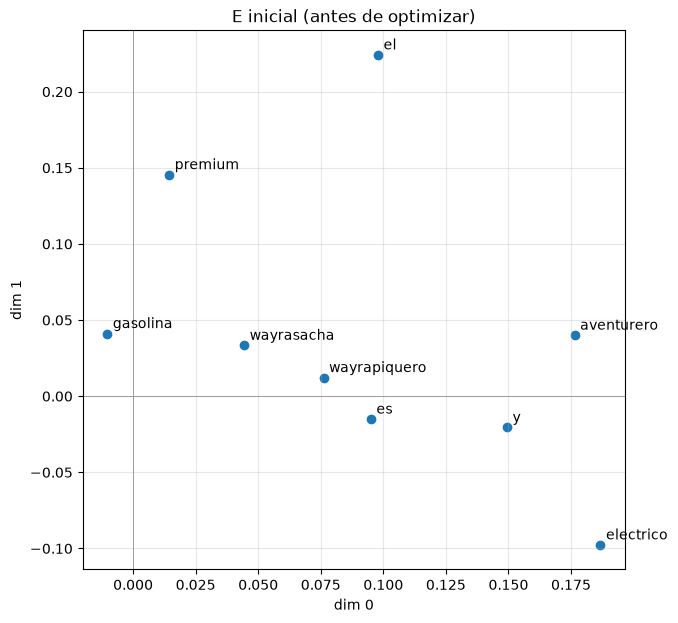

In [26]:
import matplotlib.pyplot as plt

E_init = E.copy()  # snapshot: positions before training

plt.figure(figsize=(7, 7))
plt.scatter(E_init[:, 0], E_init[:, 1])
for i, word in idx2word.items():
    plt.annotate(word, E_init[i], xytext=(4, 4), textcoords="offset points")
plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.xlabel("dim 0")
plt.ylabel("dim 1")
plt.title("E inicial (antes de optimizar)")
plt.grid(True, alpha=0.3)
plt.show()


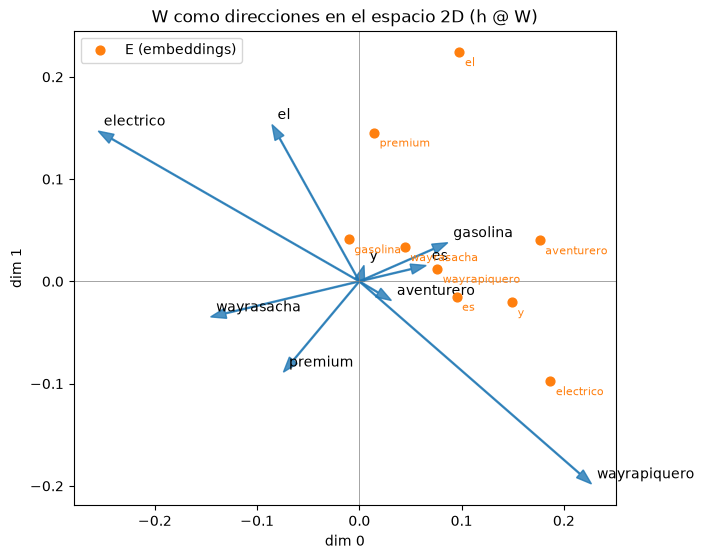

In [25]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7, 7))

# Columnas de W: dirección de cada palabra en el espacio de entrada (dim=2)
for j, word in idx2word.items():
    wx, wy = W[:, j]
    plt.arrow(
        0, 0, wx, wy,
        head_width=0.01, head_length=0.015,
        length_includes_head=True, color="C0", alpha=0.8,
    )
    plt.annotate(word, (wx, wy), xytext=(4, 4), textcoords="offset points")

# Opcional: embeddings E en el mismo plano (para comparar)
plt.scatter(E[:, 0], E[:, 1], color="C1", s=40, label="E (embeddings)", zorder=3)
for i, word in idx2word.items():
    plt.annotate(word, E[i], xytext=(4, -10), textcoords="offset points", color="C1", fontsize=8)

plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.gca().set_aspect("equal")
plt.xlabel("dim 0")
plt.ylabel("dim 1")
plt.title("W como direcciones en el espacio 2D (h @ W)")
plt.legend()
plt.show()

In [27]:
h = get_embedding("wayrapiquero", word2idx, E)
h

array([0.07610377, 0.0121675 ])

In [28]:
def linear(h, W, b):
    return h @ W + b

In [29]:
logits = linear(h, W, b)

In [30]:
logits

array([ 0.00215481, -0.00463498, -0.01764137,  0.00516282,  0.00703881,
       -0.00672837,  0.01486355, -0.01149159,  0.00053848])

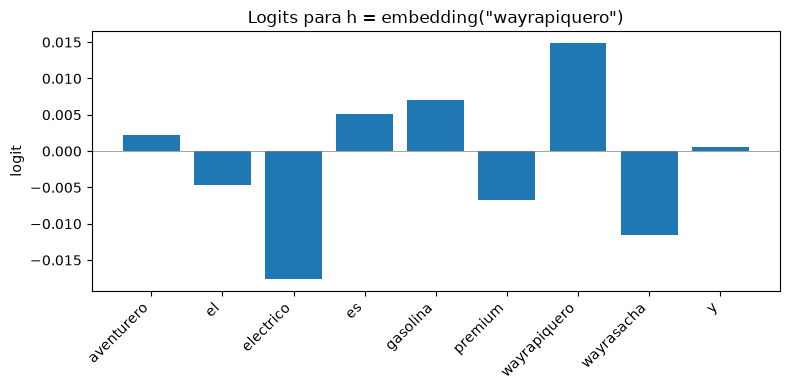

In [31]:
import matplotlib.pyplot as plt

words = [idx2word[i] for i in range(len(logits))]

plt.figure(figsize=(8, 4))
plt.bar(words, logits)
plt.axhline(0, color="gray", linewidth=0.5)
plt.xticks(rotation=45, ha="right")
plt.ylabel("logit")
plt.title('Logits para h = embedding("wayrapiquero")')
plt.tight_layout()
plt.show()

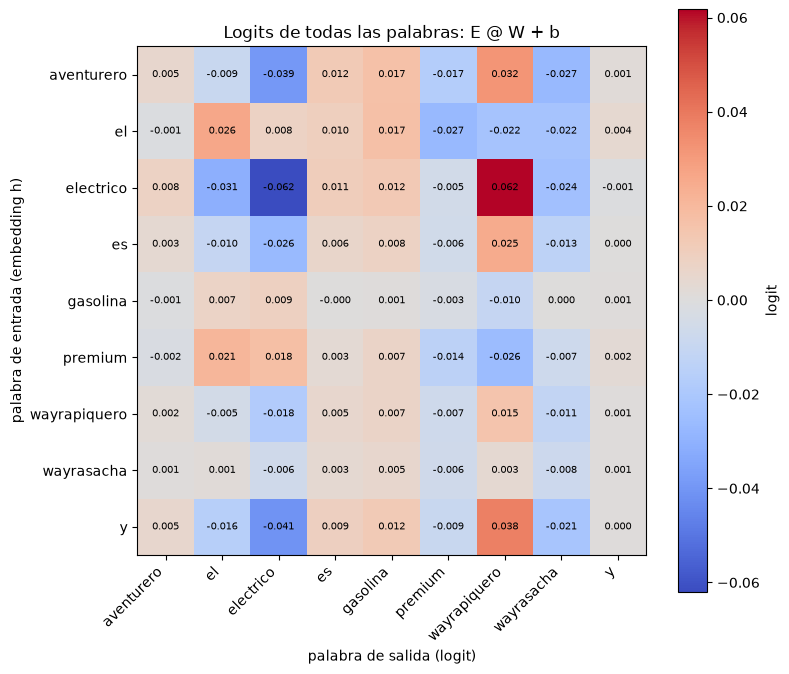

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Matriz (vocab × vocab): logits[i, j] = score de palabra j dado embedding de i
all_logits = E @ W + b
words = [idx2word[i] for i in range(len(vocab))]

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(all_logits, cmap="coolwarm", aspect="equal")

ax.set_xticks(range(len(words)))
ax.set_yticks(range(len(words)))
ax.set_xticklabels(words, rotation=45, ha="right")
ax.set_yticklabels(words)
ax.set_xlabel("palabra de salida (logit)")
ax.set_ylabel("palabra de entrada (embedding h)")
ax.set_title("Logits de todas las palabras: E @ W + b")

for i in range(len(words)):
    for j in range(len(words)):
        ax.text(j, i, f"{all_logits[i, j]:.3f}", ha="center", va="center", fontsize=7)

fig.colorbar(im, ax=ax, label="logit")
plt.tight_layout()
plt.show()

In [33]:
def forward(ctx_word, target_word, word2idx, E, W, b):
    ci, ti = word2idx[ctx_word], word2idx[target_word]
    h = E[ci]
    logits = h @ W + b
    e = np.exp(logits - logits.max())
    probs = e / e.sum()
    loss = -np.log(probs[ti] + 1e-9)
    return h, logits, probs, loss

# Parte 5: backward
def backward(h, probs, target_idx, W):
    dlogits = probs.copy()
    dlogits[target_idx] -= 1
    dW = np.outer(h, dlogits)
    db = dlogits
    dh = W @ dlogits
    return dW, db, dh

In [34]:
epochs=3000
lr=0.15
l2=0.01
seed=0


for epoch in range(epochs):
    for ctx, tgt in pairs:
        h, logits, probs, loss = forward(ctx, tgt, word2idx, E, W, b)
        dW, db, dh = backward(h, probs, word2idx[tgt], W)
        dW += l2 * W
        dh += l2 * h
        E[word2idx[ctx]] -= lr * dh
        W -= lr * dW
        b -= lr * db

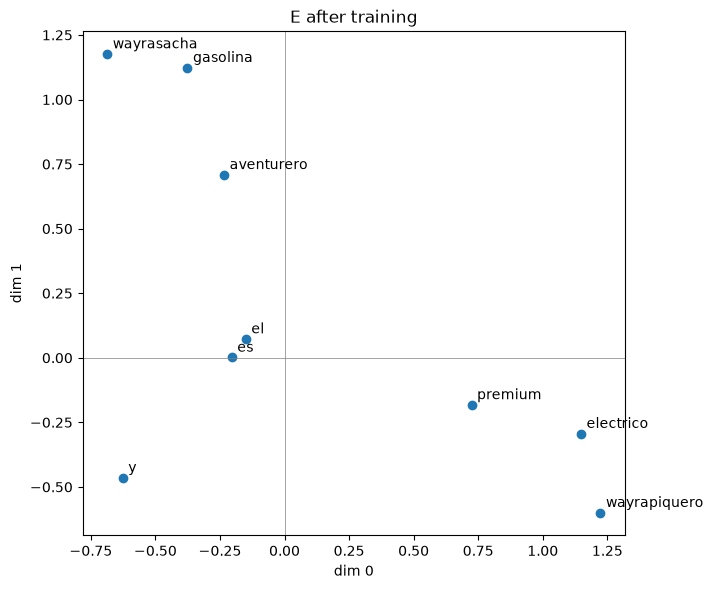

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.scatter(E[:, 0], E[:, 1])
for i, word in idx2word.items():
    plt.annotate(word, E[i], xytext=(4, 4), textcoords="offset points")
plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.gca().set_aspect("equal")
plt.xlabel("dim 0")
plt.ylabel("dim 1")
plt.title("E after training")
plt.show()

In [36]:
def get_embedding(word, word2idx, E):
    return E[word2idx[word]]

In [40]:
word2idx

{'aventurero': 0,
 'el': 1,
 'electrico': 2,
 'es': 3,
 'gasolina': 4,
 'premium': 5,
 'wayrapiquero': 6,
 'wayrasacha': 7,
 'y': 8}

In [39]:
v = get_embedding("wayrapiquero", word2idx, E)
v

array([ 1.22328504, -0.59925377])

In [42]:
v1 = get_embedding("wayrapiquero", word2idx, E)
v2 = get_embedding("gasolina", word2idx, E)

In [ ]:
def cosine(E, word2idx, word_a, word_b):
    va, vb = E[word2idx[word_a]], E[word2idx[word_b]]
    return float(np.dot(va, vb) / (np.linalg.norm(va) * np.linalg.norm(vb)))

In [ ]:
cosine(E, word2idx, "aventurero", "gasolina")

0.9999921538390717

In [ ]:
cosine(E, word2idx, "wayrapiquero", "electrico")

0.9789821264611774

In [50]:
def predict(word, word2idx, idx2word, E, W, b, topk=3):
    h = E[word2idx[word]]
    logits = h @ W + b
    e = np.exp(logits - logits.max())
    probs = e / e.sum()
    top = np.argsort(-probs)[:topk]
    return [(idx2word[i], probs[i]) for i in top]

In [49]:
predict("wayrapiquero", word2idx, idx2word, E, W, b)

[('y', np.float64(0.1860262250294611)),
 ('premium', np.float64(0.16127353120396307)),
 ('es', np.float64(0.1578537622922808))]

In [51]:
def embed_text(text, word2idx, E, dim):
    words = [w for w in text.split() if w in word2idx]
    if not words:
        return np.zeros(dim)
    vecs = [E[word2idx[w]] for w in words]
    return np.mean(vecs, axis=0)

def retrieve(query, index, word2idx, E, dim, topk=1):
    qvec = embed_text(query, word2idx, E, dim)
    sims = []
    for name, dvec in index.items():
        qn, dn = np.linalg.norm(qvec), np.linalg.norm(dvec)
        sim = 0.0 if qn == 0 or dn == 0 else float(np.dot(qvec, dvec) / (qn * dn))
        sims.append((name, sim))
    return sorted(sims, key=lambda x: -x[1])[:topk]

In [55]:
dim = 2

documents = {
    "wayrapiquero": "el wayrapiquero es electrico y premium",
    "wayrasacha": "el wayrasacha es gasolina y aventurero",
}

# 3. Build the index (THIS defines `index`)
index = {name: embed_text(text, word2idx, E, dim) for name, text in documents.items()}

# 4. Now retrieve() works
result = retrieve("premium electrico", index, word2idx, E, dim, topk=2)
print(result)

[('wayrapiquero', 0.9370396688524922), ('wayrasacha', -0.8214170415340352)]


In [57]:
def embed_text(text, word2idx, E, dim):
    words = [w for w in text.split() if w in word2idx]
    if not words:
        return np.zeros(dim)
    vecs = [E[word2idx[w]] for w in words]
    return np.mean(vecs, axis=0)

In [70]:
embed_text("premium electrico", word2idx, E, dim)

array([ 0.93609631, -0.23762377])

In [75]:
text = "premium electrico"

words = [w for w in text.split() if w in word2idx]
if not words:
    print(np.zeros(dim))
vecs = [E[word2idx[w]] for w in words]
print(vecs)

[array([ 0.72414104, -0.18194792]), array([ 1.14805158, -0.29329962])]


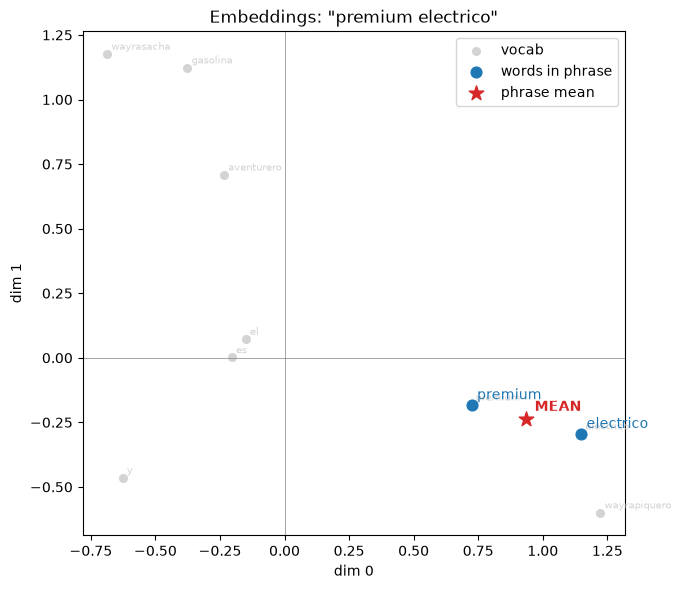

In [77]:
import matplotlib.pyplot as plt
import numpy as np

text = "premium electrico"
words = [w for w in text.split() if w in word2idx]
vecs = np.array([E[word2idx[w]] for w in words])
centroid = vecs.mean(axis=0)

plt.figure(figsize=(7, 7))

# all vocab (faded context)
plt.scatter(E[:, 0], E[:, 1], color="lightgray", s=30, label="vocab")
for i, w in idx2word.items():
    plt.annotate(w, E[i], color="lightgray", fontsize=7, xytext=(3, 3), textcoords="offset points")

# phrase word embeddings
plt.scatter(vecs[:, 0], vecs[:, 1], color="C0", s=60, zorder=3, label="words in phrase")
for w, v in zip(words, vecs):
    plt.annotate(w, v, xytext=(4, 4), textcoords="offset points", color="C0")

# phrase mean embedding
plt.scatter(centroid[0], centroid[1], color="C3", s=120, marker="*", zorder=4, label="phrase mean")
plt.annotate("MEAN", centroid, xytext=(6, 6), textcoords="offset points", color="C3", fontweight="bold")

plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.gca().set_aspect("equal")
plt.xlabel("dim 0")
plt.ylabel("dim 1")
plt.title(f'Embeddings: "{text}"')
plt.legend()
plt.show()

In [78]:
qvec = embed_text("premium electrico", word2idx, E, dim)

In [79]:
qvec

array([ 0.93609631, -0.23762377])

In [80]:

query = "premium electrico"
words = [w for w in query.split() if w in word2idx]
vecs = np.array([E[word2idx[w]] for w in words])
centroid = embed_text(query, word2idx, E, dim)

In [81]:
centroid

array([ 0.93609631, -0.23762377])

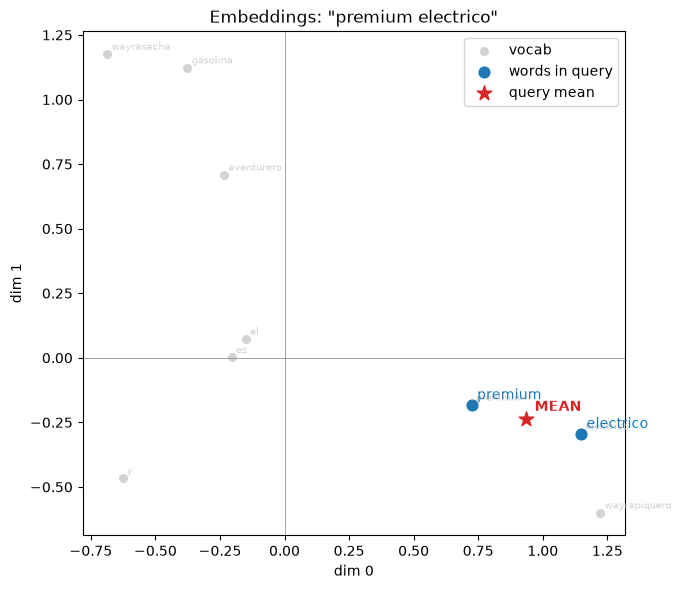

In [82]:
import matplotlib.pyplot as plt
import numpy as np


plt.figure(figsize=(7, 7))

plt.scatter(E[:, 0], E[:, 1], color="lightgray", s=30, label="vocab")
for i, w in idx2word.items():
    plt.annotate(w, E[i], color="lightgray", fontsize=7, xytext=(3, 3), textcoords="offset points")

plt.scatter(vecs[:, 0], vecs[:, 1], color="C0", s=60, zorder=3, label="words in query")
for w, v in zip(words, vecs):
    plt.annotate(w, v, xytext=(4, 4), textcoords="offset points", color="C0")

plt.scatter(centroid[0], centroid[1], color="C3", s=120, marker="*", zorder=4, label="query mean")
plt.annotate("MEAN", centroid, xytext=(6, 6), textcoords="offset points", color="C3", fontweight="bold")

plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.gca().set_aspect("equal")
plt.xlabel("dim 0")
plt.ylabel("dim 1")
plt.title(f'Embeddings: "{query}"')
plt.legend()
plt.show()
